# OBD Resource Comparison Analysis

This notebook compares resource usage across the four OBD experiment variants in a single analysis:

- Gemma 3 270M + soft prompt
- Gemma 3 270M + Flamingo alignment
- Llama 3.2 1B + soft prompt
- Llama 3.2 1B + Flamingo alignment

Goals:
- compare training and inference cost across all runs
- visualize CPU, RAM, GPU memory, latency, and optimization stability in unified figures
- make the article-ready comparison easier to read at a glance


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'results').exists() and (PROJECT_ROOT.parent / 'results').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

METRICS_DIR = PROJECT_ROOT / 'results' / 'notebook_metrics'

RUNS = [
    {
        'run_id': 'gemma_soft_prompt',
        'label': 'Gemma + Soft Prompt',
        'approach': 'Soft Prompt',
        'model': 'Gemma 3 270M',
        'prefix': 'obd_soft_prompt_gemma_3_270m',
    },
    {
        'run_id': 'gemma_flamingo',
        'label': 'Gemma + Flamingo',
        'approach': 'Flamingo',
        'model': 'Gemma 3 270M',
        'prefix': 'obd_flamingo_gemma_3_270m',
    },
    {
        'run_id': 'llama_soft_prompt',
        'label': 'Llama + Soft Prompt',
        'approach': 'Soft Prompt',
        'model': 'Llama 3.2 1B',
        'prefix': 'obd_soft_prompt_llama_3_2_1b',
    },
    {
        'run_id': 'llama_flamingo',
        'label': 'Llama + Flamingo',
        'approach': 'Flamingo',
        'model': 'Llama 3.2 1B',
        'prefix': 'obd_flamingo_llama_3_2_1b',
    },
]

RUN_ORDER = [run['label'] for run in RUNS]
RUN_PALETTE = {
    'Gemma + Soft Prompt': '#1f77b4',
    'Gemma + Flamingo': '#ff7f0e',
    'Llama + Soft Prompt': '#2ca02c',
    'Llama + Flamingo': '#d62728',
}

for run in RUNS:
    prefix = run['prefix']
    expected = [
        METRICS_DIR / f'{prefix}_train_samples.csv',
        METRICS_DIR / f'{prefix}_train_summary.json',
        METRICS_DIR / f'{prefix}_inference_samples.csv',
        METRICS_DIR / f'{prefix}_inference_summary.json',
    ]
    status = ['FOUND' if path.exists() else 'MISSING' for path in expected]
    print(run['label'])
    for path, marker in zip(expected, status):
        print('  ', path.name, marker)


Gemma + Soft Prompt
   obd_soft_prompt_gemma_3_270m_train_samples.csv FOUND
   obd_soft_prompt_gemma_3_270m_train_summary.json FOUND
   obd_soft_prompt_gemma_3_270m_inference_samples.csv FOUND
   obd_soft_prompt_gemma_3_270m_inference_summary.json FOUND
Gemma + Flamingo
   obd_flamingo_gemma_3_270m_train_samples.csv FOUND
   obd_flamingo_gemma_3_270m_train_summary.json FOUND
   obd_flamingo_gemma_3_270m_inference_samples.csv FOUND
   obd_flamingo_gemma_3_270m_inference_summary.json FOUND
Llama + Soft Prompt
   obd_soft_prompt_llama_3_2_1b_train_samples.csv FOUND
   obd_soft_prompt_llama_3_2_1b_train_summary.json FOUND
   obd_soft_prompt_llama_3_2_1b_inference_samples.csv FOUND
   obd_soft_prompt_llama_3_2_1b_inference_summary.json FOUND
Llama + Flamingo
   obd_flamingo_llama_3_2_1b_train_samples.csv FOUND
   obd_flamingo_llama_3_2_1b_train_summary.json FOUND
   obd_flamingo_llama_3_2_1b_inference_samples.csv FOUND
   obd_flamingo_llama_3_2_1b_inference_summary.json FOUND


In [3]:
def load_summary(path: Path) -> dict:
    return json.loads(path.read_text(encoding='utf-8'))


def bytes_to_gib(series: pd.Series) -> pd.Series:
    return series / (1024 ** 3)


def add_common_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if 'timestamp_utc' in df.columns:
        df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'], utc=True, errors='coerce')
    if 'elapsed_s' in df.columns:
        df['elapsed_min'] = df['elapsed_s'] / 60.0
        max_elapsed = df['elapsed_s'].dropna().max()
        df['progress_pct'] = np.where(max_elapsed > 0, (df['elapsed_s'] / max_elapsed) * 100.0, np.nan)
    else:
        df['elapsed_min'] = np.nan
        df['progress_pct'] = np.nan

    for col in [
        'process_rss_bytes',
        'system_ram_used_bytes',
        'cuda_0_memory_allocated_bytes',
        'cuda_0_memory_reserved_bytes',
        'cuda_0_max_memory_allocated_bytes',
    ]:
        if col in df.columns:
            df[col.replace('_bytes', '_gib')] = bytes_to_gib(df[col])
    return df


def build_run_tables(run: dict) -> dict:
    prefix = run['prefix']
    train_samples_path = METRICS_DIR / f'{prefix}_train_samples.csv'
    train_summary_path = METRICS_DIR / f'{prefix}_train_summary.json'
    infer_samples_path = METRICS_DIR / f'{prefix}_inference_samples.csv'
    infer_summary_path = METRICS_DIR / f'{prefix}_inference_summary.json'

    train_df = add_common_columns(pd.read_csv(train_samples_path))
    infer_df = add_common_columns(pd.read_csv(infer_samples_path))
    train_summary = load_summary(train_summary_path)
    infer_summary = load_summary(infer_summary_path)

    metadata_cols = {
        'run_id': run['run_id'],
        'label': run['label'],
        'approach': run['approach'],
        'model': run['model'],
    }

    for df in [train_df, infer_df]:
        for key, value in metadata_cols.items():
            df[key] = value

    train_epoch = train_df[train_df['phase'] == 'epoch_end'].copy()
    train_steps = train_df[train_df['phase'] == 'train_step'].copy()
    train_background = train_df[train_df['phase'].isin(['sample', 'train_step', 'epoch_end', 'checkpoint_saved', 'finished'])].copy()
    train_checkpoints = train_df[train_df['phase'] == 'checkpoint_saved'].copy()
    infer_steps = infer_df[infer_df['phase'] == 'inference_step'].copy()
    infer_background = infer_df[infer_df['phase'].isin(['sample', 'inference_step', 'finished'])].copy()

    for df in [train_epoch, train_steps, train_background, train_checkpoints, infer_steps, infer_background]:
        for key, value in metadata_cols.items():
            df[key] = value

    best_epoch = np.nan
    best_val_loss = np.nan
    if not train_epoch.empty and 'val_loss' in train_epoch.columns:
        best_idx = train_epoch['val_loss'].idxmin()
        best_epoch = int(train_epoch.loc[best_idx, 'epoch'])
        best_val_loss = float(train_epoch.loc[best_idx, 'val_loss'])

    summary_row = {
        **metadata_cols,
        'train_duration_min': train_summary.get('total_duration_s', np.nan) / 60.0,
        'inference_duration_min': infer_summary.get('total_duration_s', np.nan) / 60.0,
        'train_sample_count': train_summary.get('sample_count', np.nan),
        'inference_sample_count': infer_summary.get('sample_count', np.nan),
        'epochs': int(train_epoch['epoch'].nunique()) if 'epoch' in train_epoch.columns and not train_epoch.empty else np.nan,
        'best_epoch': best_epoch,
        'best_val_loss': best_val_loss,
        'last_val_loss': float(train_epoch['val_loss'].iloc[-1]) if not train_epoch.empty and 'val_loss' in train_epoch.columns else np.nan,
        'mean_train_step_time_s': float(train_steps['step_duration_s'].dropna().mean()) if 'step_duration_s' in train_steps.columns and not train_steps.empty else np.nan,
        'p95_train_step_time_s': float(train_steps['step_duration_s'].dropna().quantile(0.95)) if 'step_duration_s' in train_steps.columns and not train_steps.empty else np.nan,
        'mean_grad_norm': float(train_steps['grad_norm'].dropna().mean()) if 'grad_norm' in train_steps.columns and not train_steps.empty else np.nan,
        'mean_inference_latency_s': float(infer_steps['inference_latency_s'].dropna().mean()) if 'inference_latency_s' in infer_steps.columns and not infer_steps.empty else np.nan,
        'p95_inference_latency_s': float(infer_steps['inference_latency_s'].dropna().quantile(0.95)) if 'inference_latency_s' in infer_steps.columns and not infer_steps.empty else np.nan,
        'peak_train_gpu_alloc_gib': train_summary.get('cuda_0_max_memory_allocated_bytes_max', np.nan) / (1024 ** 3),
        'peak_train_gpu_reserved_gib': train_summary.get('cuda_0_max_memory_reserved_bytes_max', np.nan) / (1024 ** 3),
        'peak_train_rss_gib': train_summary.get('process_rss_bytes_max', np.nan) / (1024 ** 3),
        'peak_infer_gpu_alloc_gib': infer_summary.get('cuda_0_max_memory_allocated_bytes_max', np.nan) / (1024 ** 3),
        'peak_infer_gpu_reserved_gib': infer_summary.get('cuda_0_max_memory_reserved_bytes_max', np.nan) / (1024 ** 3),
        'peak_infer_rss_gib': infer_summary.get('process_rss_bytes_max', np.nan) / (1024 ** 3),
    }

    return {
        'train_df': train_df,
        'infer_df': infer_df,
        'train_epoch': train_epoch,
        'train_steps': train_steps,
        'train_background': train_background,
        'train_checkpoints': train_checkpoints,
        'infer_steps': infer_steps,
        'infer_background': infer_background,
        'summary_row': summary_row,
    }


run_tables = [build_run_tables(run) for run in RUNS]

overview = pd.DataFrame([table['summary_row'] for table in run_tables]).copy()
overview['overfit_gap'] = overview['last_val_loss'] - overview['best_val_loss']
overview['label'] = pd.Categorical(overview['label'], categories=RUN_ORDER, ordered=True)
overview = overview.sort_values('label').reset_index(drop=True)

train_epoch_df = pd.concat([table['train_epoch'] for table in run_tables], ignore_index=True)
train_steps_df = pd.concat([table['train_steps'] for table in run_tables], ignore_index=True)
train_background_df = pd.concat([table['train_background'] for table in run_tables], ignore_index=True)
infer_steps_df = pd.concat([table['infer_steps'] for table in run_tables], ignore_index=True)
infer_background_df = pd.concat([table['infer_background'] for table in run_tables], ignore_index=True)

for df in [train_epoch_df, train_steps_df, train_background_df, infer_steps_df, infer_background_df]:
    df['label'] = pd.Categorical(df['label'], categories=RUN_ORDER, ordered=True)

print('Runs loaded:', len(overview))
print('Training step rows:', len(train_steps_df))
print('Inference step rows:', len(infer_steps_df))


Runs loaded: 4
Training step rows: 2726
Inference step rows: 156


## Consolidated Overview

This table puts the four approaches side by side so the main cost and stability indicators are visible in one place.


In [4]:
overview_display = overview[[
    'label', 'model', 'approach', 'epochs', 'best_epoch', 'best_val_loss', 'overfit_gap',
    'train_duration_min', 'mean_train_step_time_s', 'p95_train_step_time_s',
    'peak_train_gpu_alloc_gib', 'peak_train_rss_gib',
    'inference_duration_min', 'mean_inference_latency_s', 'p95_inference_latency_s',
    'peak_infer_gpu_alloc_gib', 'peak_infer_rss_gib',
]].copy()

display(overview_display.round(3))


,label,model,approach,epochs,best_epoch,best_val_loss,overfit_gap,train_duration_min,mean_train_step_time_s,p95_train_step_time_s,peak_train_gpu_alloc_gib,peak_train_rss_gib,inference_duration_min,mean_inference_latency_s,p95_inference_latency_s,peak_infer_gpu_alloc_gib,peak_infer_rss_gib
0,Gemma + Soft Prompt,Gemma 3 270M,Soft Prompt,12,9,2.258,0.176,3.513,0.260,0.796,7.399,13.280,5.598,8.611,10.121,0.623,13.583
1,Gemma + Flamingo,Gemma 3 270M,Flamingo,18,15,2.275,0.110,6.624,0.324,0.820,8.377,14.614,2.690,4.138,6.201,2.357,14.381
2,Llama + Soft Prompt,Llama 3.2 1B,Soft Prompt,9,6,1.898,0.206,3.485,0.344,0.374,10.286,13.533,1.664,2.559,3.295,2.581,13.528
3,Llama + Flamingo,Llama 3.2 1B,Flamingo,8,5,1.877,0.329,28.449,3.526,4.083,14.367,9.671,1.613,2.481,3.183,8.230,9.342


## Summary Scorecards

These bar charts compare the four runs directly on the metrics that usually matter most for a systems discussion.


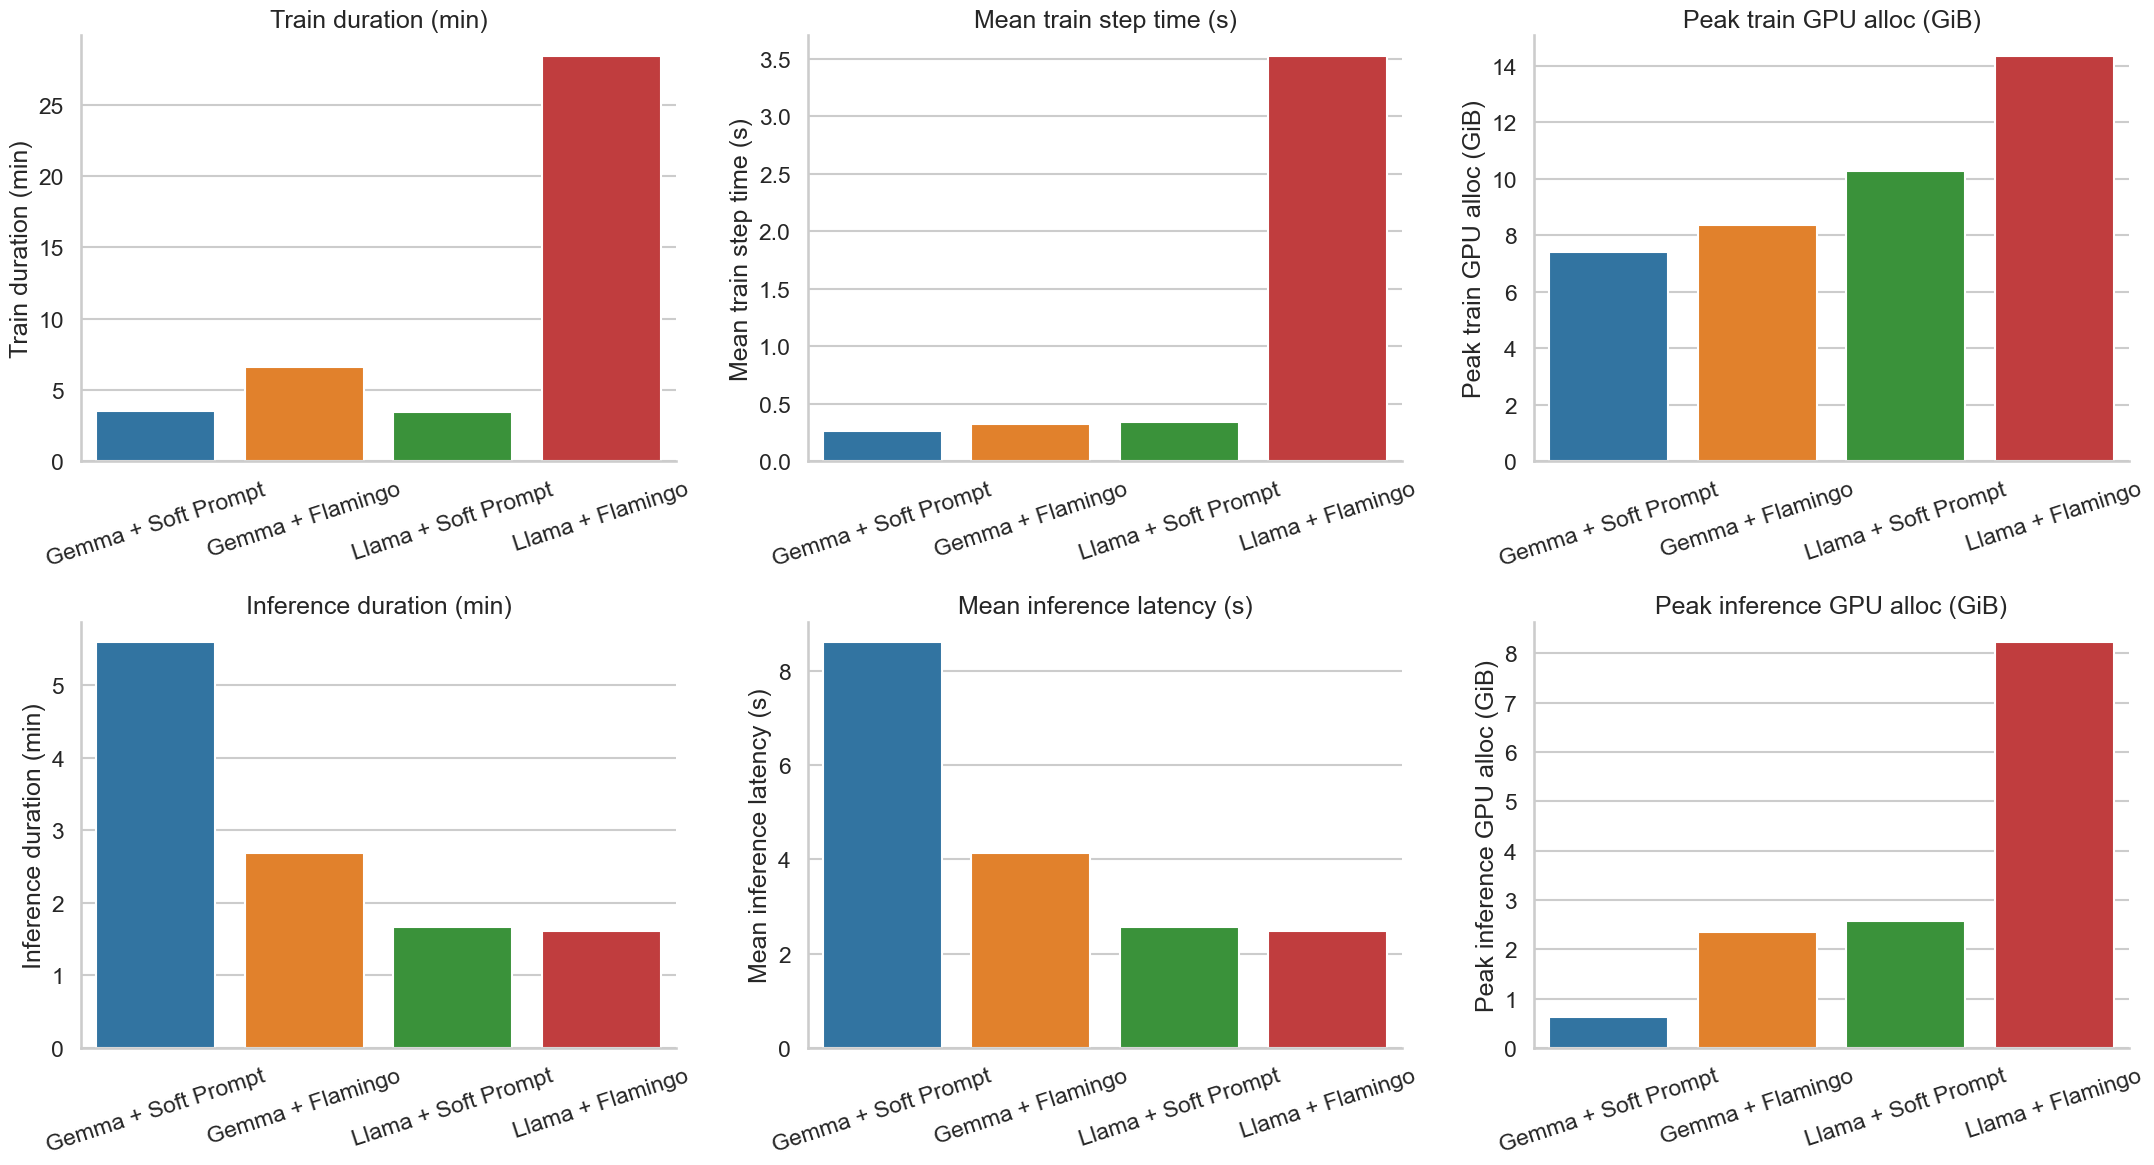

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(22, 12))

summary_plots = [
    ('train_duration_min', 'Train duration (min)'),
    ('mean_train_step_time_s', 'Mean train step time (s)'),
    ('peak_train_gpu_alloc_gib', 'Peak train GPU alloc (GiB)'),
    ('inference_duration_min', 'Inference duration (min)'),
    ('mean_inference_latency_s', 'Mean inference latency (s)'),
    ('peak_infer_gpu_alloc_gib', 'Peak inference GPU alloc (GiB)'),
]

for ax, (metric, title) in zip(axes.flat, summary_plots):
    sns.barplot(data=overview, x='label', y=metric, hue='label', palette=RUN_PALETTE, dodge=False, legend=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel(title)
    ax.tick_params(axis='x', rotation=18)

plt.tight_layout()
plt.show()


## Training Dynamics Comparison

The plots below compare optimization behavior and train-time cost in unified views. Progress is normalized so runs with different lengths remain comparable.


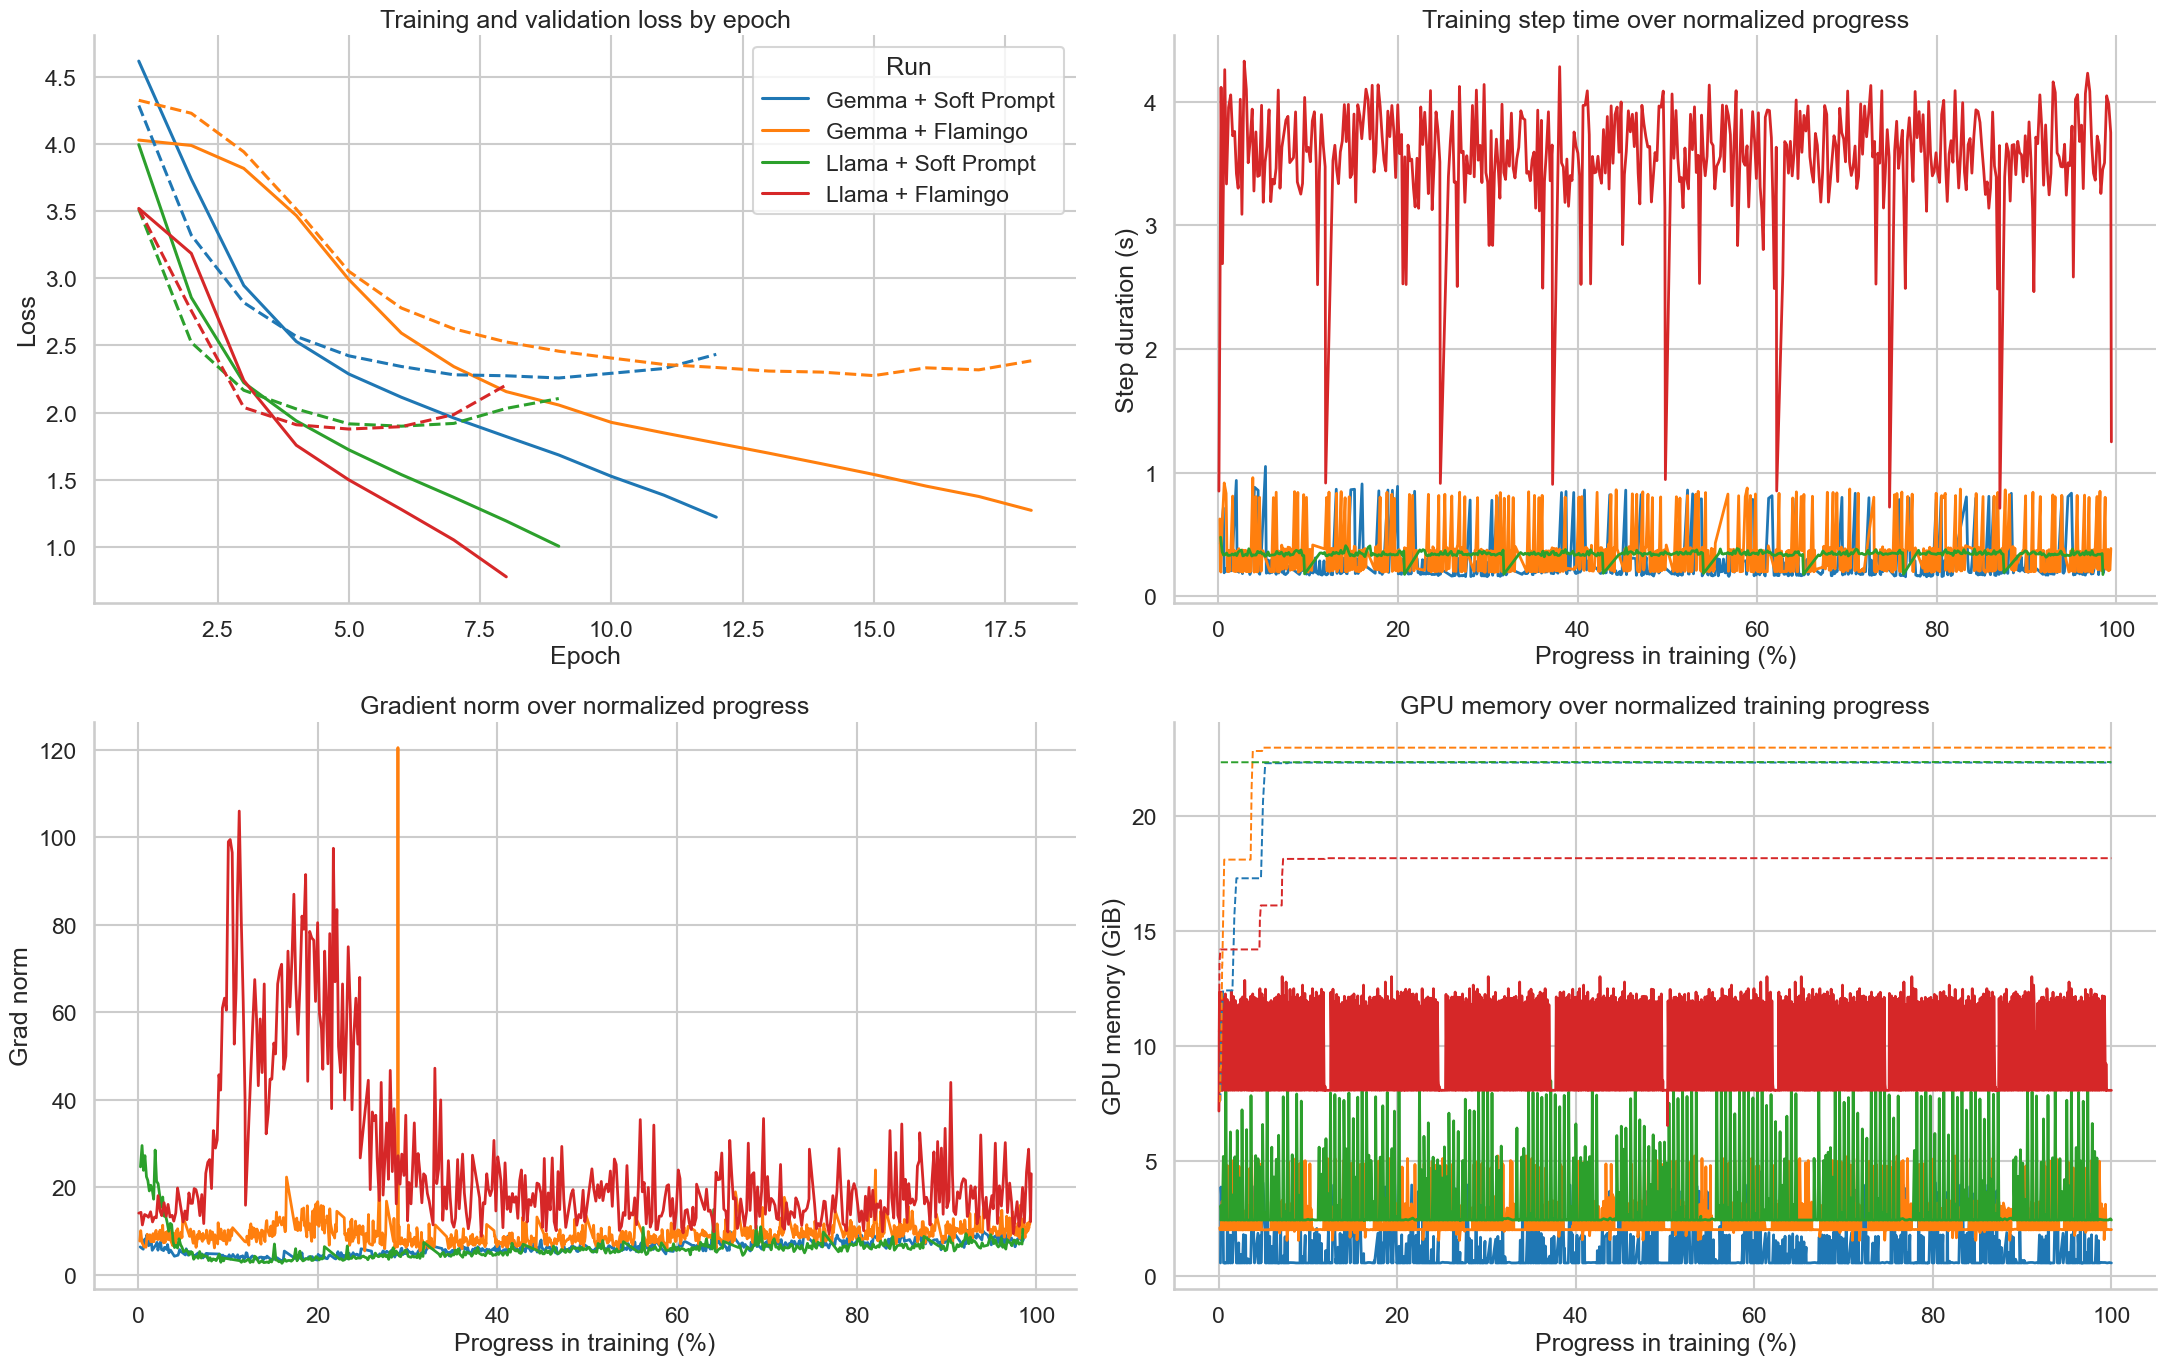

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(22, 14))

sns.lineplot(data=train_epoch_df, x='epoch', y='train_loss', hue='label', palette=RUN_PALETTE, linewidth=2.2, ax=axes[0, 0])
sns.lineplot(data=train_epoch_df, x='epoch', y='val_loss', hue='label', palette=RUN_PALETTE, linestyle='--', linewidth=2.2, legend=False, ax=axes[0, 0])
axes[0, 0].set_title('Training and validation loss by epoch')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')

sns.lineplot(data=train_steps_df, x='progress_pct', y='step_duration_s', hue='label', palette=RUN_PALETTE, linewidth=2.0, ax=axes[0, 1])
axes[0, 1].set_title('Training step time over normalized progress')
axes[0, 1].set_xlabel('Progress in training (%)')
axes[0, 1].set_ylabel('Step duration (s)')

sns.lineplot(data=train_steps_df, x='progress_pct', y='grad_norm', hue='label', palette=RUN_PALETTE, linewidth=2.0, ax=axes[1, 0])
axes[1, 0].set_title('Gradient norm over normalized progress')
axes[1, 0].set_xlabel('Progress in training (%)')
axes[1, 0].set_ylabel('Grad norm')

sns.lineplot(data=train_background_df, x='progress_pct', y='cuda_0_memory_allocated_gib', hue='label', palette=RUN_PALETTE, linewidth=2.0, ax=axes[1, 1])
sns.lineplot(data=train_background_df, x='progress_pct', y='cuda_0_memory_reserved_gib', hue='label', palette=RUN_PALETTE, linewidth=1.4, linestyle='--', legend=False, ax=axes[1, 1])
axes[1, 1].set_title('GPU memory over normalized training progress')
axes[1, 1].set_xlabel('Progress in training (%)')
axes[1, 1].set_ylabel('GPU memory (GiB)')

handles, labels = axes[0, 0].get_legend_handles_labels()
axes[0, 0].legend(handles, labels, title='Run', loc='best')
for ax in [axes[0, 1], axes[1, 0], axes[1, 1]]:
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()

plt.tight_layout()
plt.show()


## Training Resource Comparison

This panel focuses only on resource consumption, which makes it easier to contrast the hardware footprint of the four approaches.


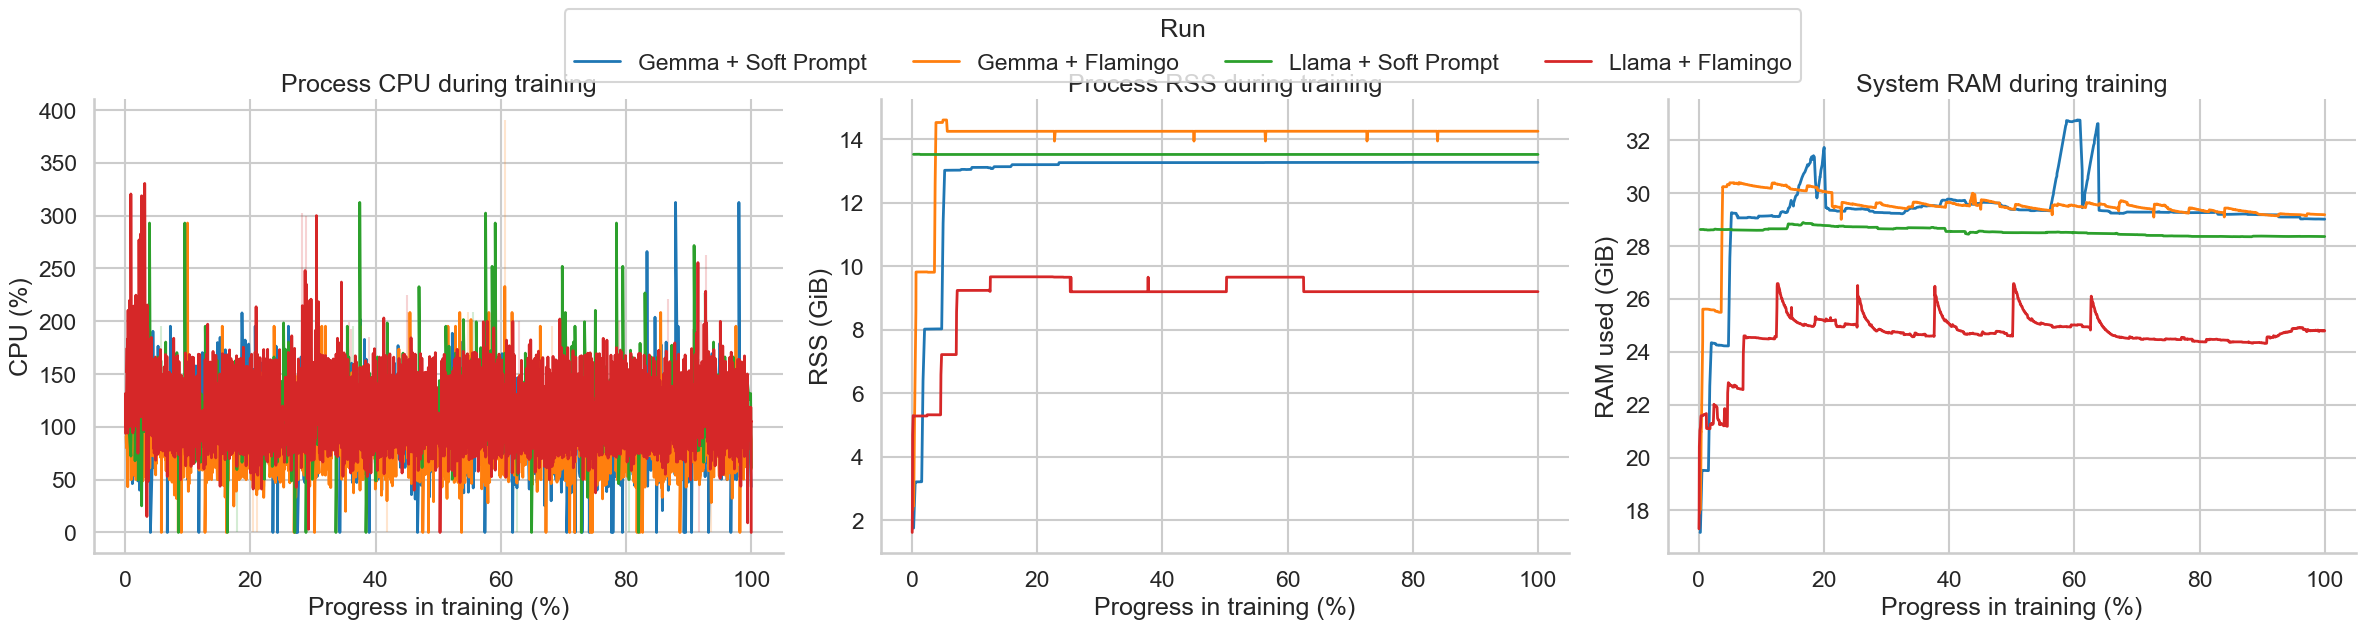

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6), sharex=True)

sns.lineplot(data=train_background_df, x='progress_pct', y='process_cpu_percent', hue='label', palette=RUN_PALETTE, linewidth=2.0, ax=axes[0])
axes[0].set_title('Process CPU during training')
axes[0].set_xlabel('Progress in training (%)')
axes[0].set_ylabel('CPU (%)')

sns.lineplot(data=train_background_df, x='progress_pct', y='process_rss_gib', hue='label', palette=RUN_PALETTE, linewidth=2.0, ax=axes[1])
axes[1].set_title('Process RSS during training')
axes[1].set_xlabel('Progress in training (%)')
axes[1].set_ylabel('RSS (GiB)')

sns.lineplot(data=train_background_df, x='progress_pct', y='system_ram_used_gib', hue='label', palette=RUN_PALETTE, linewidth=2.0, ax=axes[2])
axes[2].set_title('System RAM during training')
axes[2].set_xlabel('Progress in training (%)')
axes[2].set_ylabel('RAM used (GiB)')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Run', loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.08))
for ax in axes:
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()

plt.tight_layout()
plt.show()


## Inference Comparison

These plots compare latency and inference-time footprint across all four runs in one view.


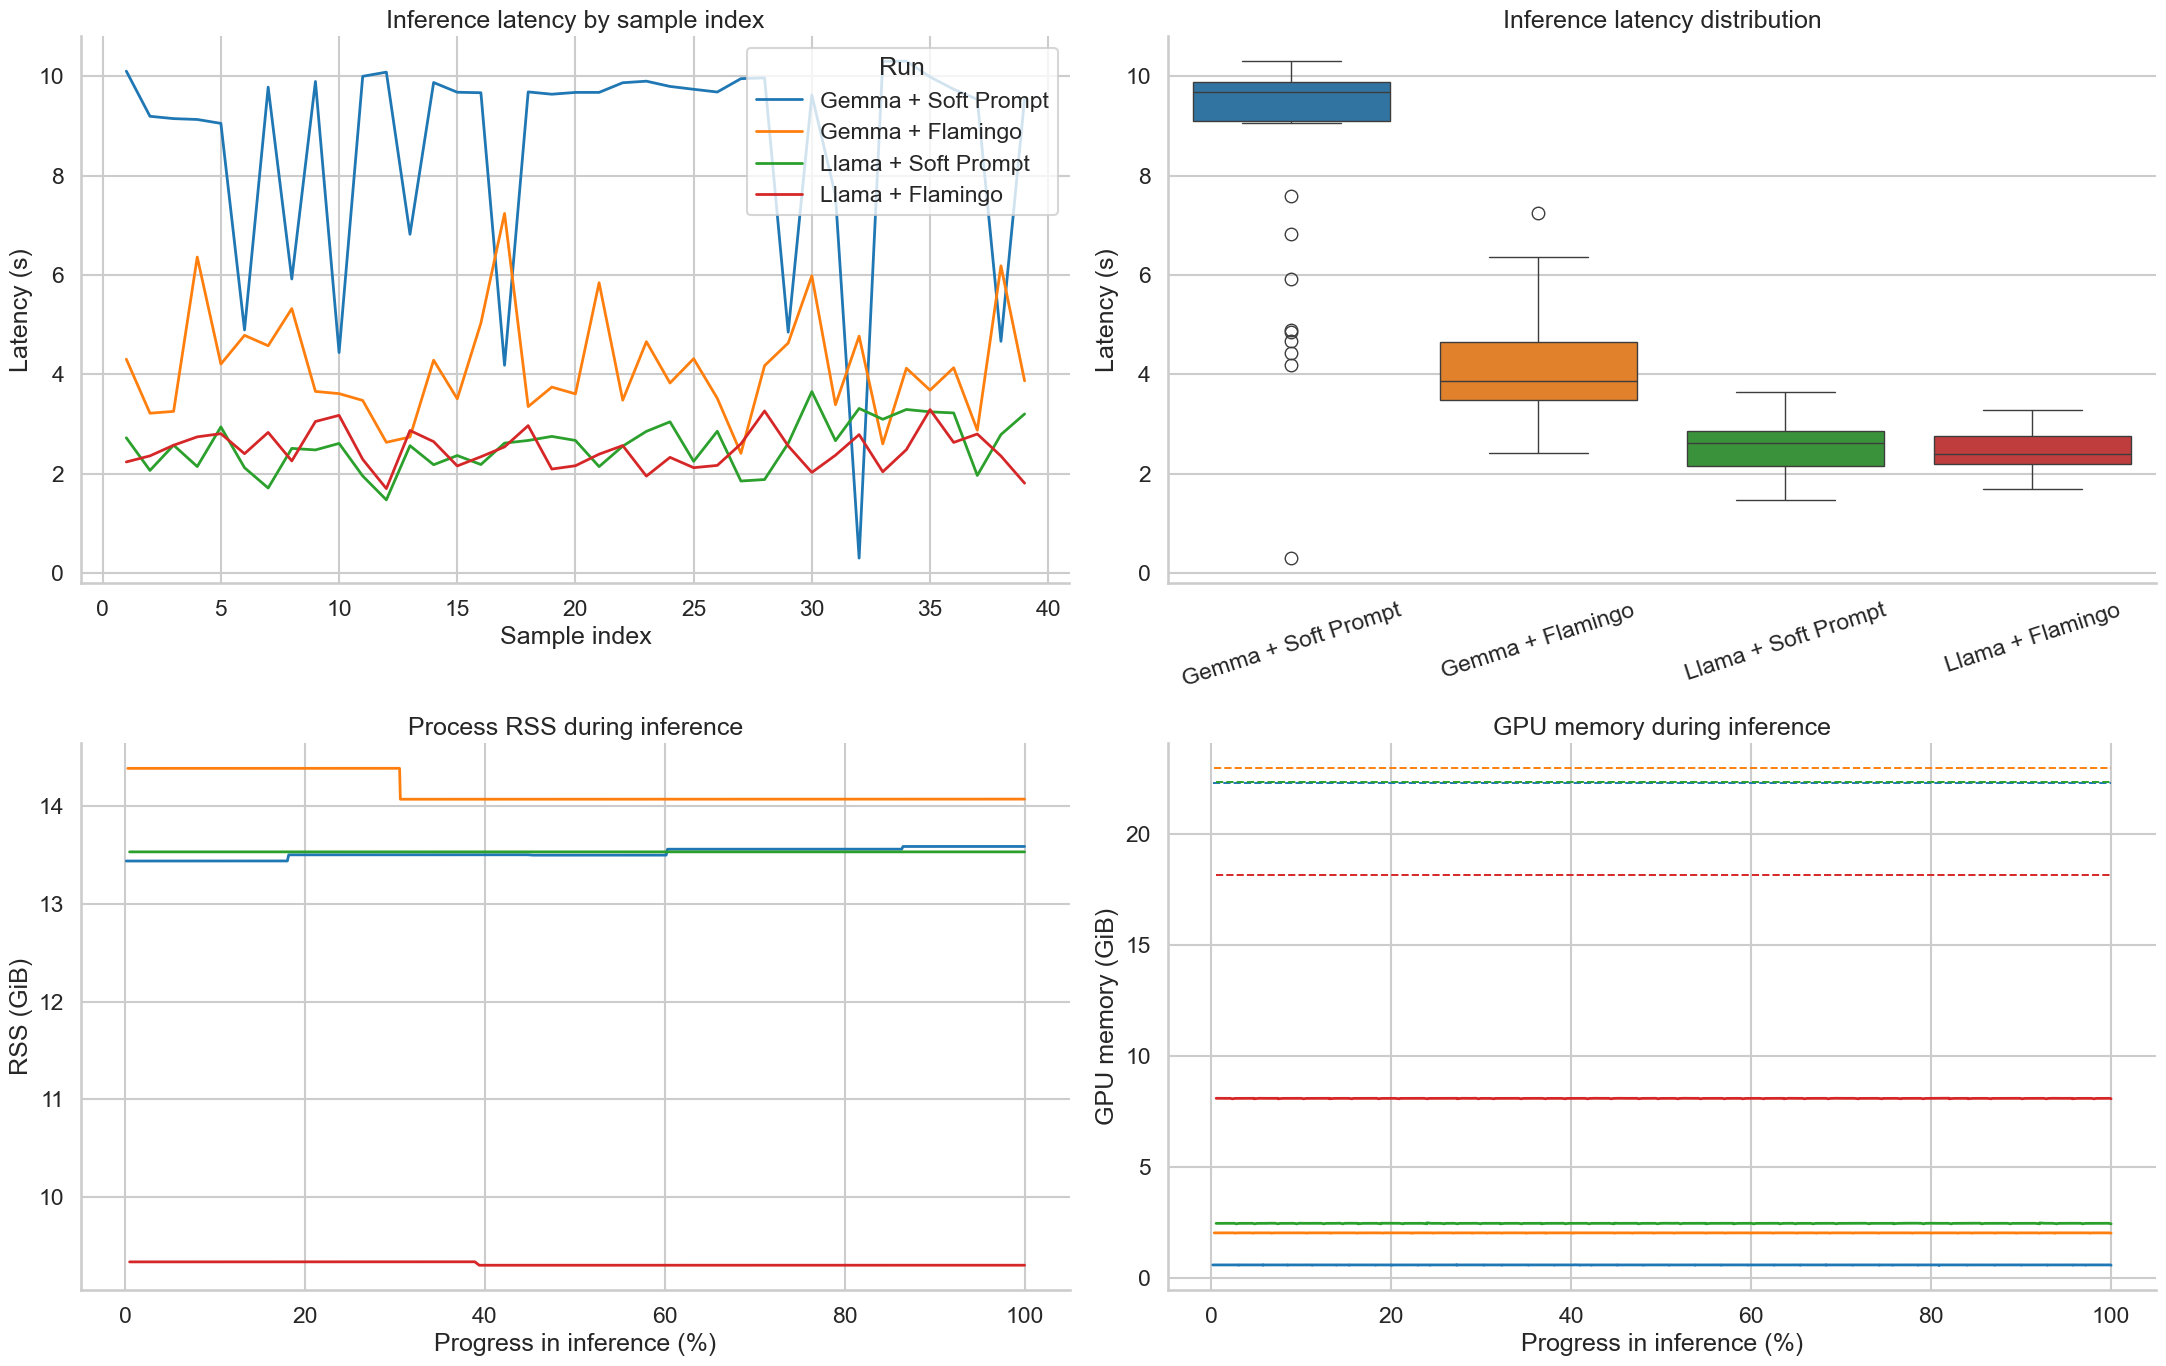

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(22, 14))

sns.lineplot(data=infer_steps_df, x='step', y='inference_latency_s', hue='label', palette=RUN_PALETTE, linewidth=2.0, ax=axes[0, 0])
axes[0, 0].set_title('Inference latency by sample index')
axes[0, 0].set_xlabel('Sample index')
axes[0, 0].set_ylabel('Latency (s)')

sns.boxplot(data=infer_steps_df, x='label', y='inference_latency_s', hue='label', palette=RUN_PALETTE, dodge=False, legend=False, ax=axes[0, 1])
axes[0, 1].set_title('Inference latency distribution')
axes[0, 1].set_xlabel('')
axes[0, 1].set_ylabel('Latency (s)')
axes[0, 1].tick_params(axis='x', rotation=18)

sns.lineplot(data=infer_background_df, x='progress_pct', y='process_rss_gib', hue='label', palette=RUN_PALETTE, linewidth=2.0, ax=axes[1, 0])
axes[1, 0].set_title('Process RSS during inference')
axes[1, 0].set_xlabel('Progress in inference (%)')
axes[1, 0].set_ylabel('RSS (GiB)')

sns.lineplot(data=infer_background_df, x='progress_pct', y='cuda_0_memory_allocated_gib', hue='label', palette=RUN_PALETTE, linewidth=2.0, ax=axes[1, 1])
sns.lineplot(data=infer_background_df, x='progress_pct', y='cuda_0_memory_reserved_gib', hue='label', palette=RUN_PALETTE, linewidth=1.4, linestyle='--', legend=False, ax=axes[1, 1])
axes[1, 1].set_title('GPU memory during inference')
axes[1, 1].set_xlabel('Progress in inference (%)')
axes[1, 1].set_ylabel('GPU memory (GiB)')

handles, labels = axes[0, 0].get_legend_handles_labels()
axes[0, 0].legend(handles, labels, title='Run', loc='best')
for ax in [axes[1, 0], axes[1, 1]]:
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()

plt.tight_layout()
plt.show()


## Automatic Comparison Notes

The cell below prints compact article-oriented takeaways from the consolidated metrics.


In [9]:
fastest_train = overview.loc[overview['train_duration_min'].idxmin()]
slowest_train = overview.loc[overview['train_duration_min'].idxmax()]
lowest_train_gpu = overview.loc[overview['peak_train_gpu_alloc_gib'].idxmin()]
highest_train_gpu = overview.loc[overview['peak_train_gpu_alloc_gib'].idxmax()]
fastest_infer = overview.loc[overview['mean_inference_latency_s'].idxmin()]
slowest_infer = overview.loc[overview['mean_inference_latency_s'].idxmax()]
best_val = overview.loc[overview['best_val_loss'].idxmin()]
lowest_overfit = overview.loc[overview['overfit_gap'].abs().idxmin()]

insights = [
    f"Fastest training: {fastest_train['label']} ({fastest_train['train_duration_min']:.2f} min). Slowest training: {slowest_train['label']} ({slowest_train['train_duration_min']:.2f} min).",
    f"Lowest peak train GPU allocation: {lowest_train_gpu['label']} ({lowest_train_gpu['peak_train_gpu_alloc_gib']:.2f} GiB). Highest: {highest_train_gpu['label']} ({highest_train_gpu['peak_train_gpu_alloc_gib']:.2f} GiB).",
    f"Fastest inference: {fastest_infer['label']} with mean latency {fastest_infer['mean_inference_latency_s']:.2f} s. Slowest inference: {slowest_infer['label']} with mean latency {slowest_infer['mean_inference_latency_s']:.2f} s.",
    f"Best validation loss: {best_val['label']} at epoch {int(best_val['best_epoch'])} with val_loss {best_val['best_val_loss']:.4f}.",
    f"Smallest train-to-best validation gap: {lowest_overfit['label']} ({lowest_overfit['overfit_gap']:.4f}), which suggests the most stable stopping behavior among the four runs.",
]

for item in insights:
    print('-', item)


- Fastest training: Llama + Soft Prompt (3.49 min). Slowest training: Llama + Flamingo (28.45 min).
- Lowest peak train GPU allocation: Gemma + Soft Prompt (7.40 GiB). Highest: Llama + Flamingo (14.37 GiB).
- Fastest inference: Llama + Flamingo with mean latency 2.48 s. Slowest inference: Gemma + Soft Prompt with mean latency 8.61 s.
- Best validation loss: Llama + Flamingo at epoch 5 with val_loss 1.8771.
- Smallest train-to-best validation gap: Gemma + Flamingo (0.1102), which suggests the most stable stopping behavior among the four runs.
